# MC62 — LEAR C-shaped Dipole — `00_test` — Rotating Coil Analysis

**Magnet**: MC62 (red bulk C-shaped dipole)
**Machine**: LEAR antiproton decelerator, CERN
**Test**: `00_test` — first test RC measurement (2026-02-11)
**Current cycle**: 0 → 100 → 200 → 100 → 0 → −100 → −200 → −100 → 0 A
**PCBs**: Integral (R45, long coil) and Central (DQ, small coil), 10 turns/plateau at −60 rpm

---
**Note on the large b2**: C-shaped dipoles have inherent left-right asymmetry (open gap
on one side, iron yoke on the other). This breaks the mid-plane symmetry that an H-dipole
would have, producing a systematic quadrupole gradient (b2) across the aperture — typically
tens of units even in a well-built magnet.

## Theoretical Background — Bottura Multipole Expansion

The magnetic field in the aperture of an accelerator magnet is described by a **2D multipole expansion** in complex notation (Bottura, *"Field Analysis Techniques"*, CERN Accelerator School, Eq. 8):

$$
B_y + i \, B_x = \sum_{n=1}^{\infty} C_n \left(\frac{x + iy}{R_{\rm ref}}\right)^{n-1}
$$

where:
- $C_n = B_n + i \, A_n$ is the complex harmonic coefficient of order $n$
- $B_n$ is the **normal** component, $A_n$ the **skew** component
- $R_{\rm ref}$ is the reference radius (here 33.0 mm)
- For a dipole ($m = 1$): $C_1 = B_1 + i\,A_1$ is the main field

### Rotating-coil measurement principle

A rotating coil with complex sensitivity $K_n$ intercepts flux $\Phi(\theta) = \sum_n K_n \, C_n \, e^{in\theta}$. The **discrete Fourier transform** of one full rotation ($N_s$ samples) yields:

$$
\hat{\Phi}_n = \frac{2}{N_s} \, \text{FFT}(\Phi)[n]
$$

The field coefficient is recovered by applying the **inverse sensitivity** (Bottura Appendix IV):

$$
C_n = \hat{\Phi}_n \cdot \frac{R_{\rm ref}^{\,n-1}}{\overline{K_n}}
$$

where $\overline{K_n}$ denotes the complex conjugate of the coil sensitivity.

### Normalised harmonics (units)

For orders $n > m$ (main harmonic order), normalised harmonics are defined as:

$$
b_n + i \, a_n = \frac{C_n}{C_m} \times 10^4
$$

giving $b_n, a_n$ in **"units"** ($10^{-4}$ relative to the main field component). For $n \leq m$, the absolute field $B_n, A_n$ in Tesla is reported directly (Bottura Section 3.7 "mixed-format" convention).


## 1. Configuration

Adjust parameters below, then **Run All**.

In [1]:
from pathlib import Path
import numpy as np

# ── Paths ──────────────────────────────────────────────────────────────
BASE_DIR    = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\measurements\MC62\2026-02-11")
TEST_DIR    = BASE_DIR / "00_test" / "20260211_104646_test_REDMAGNET"
RUN_DIR     = TEST_DIR / "20260211_105610_REDMAGNET"
KN_DIR      = BASE_DIR / "Kn values"

KN_INTEGRAL = KN_DIR / "Kn_R45_PCB_N1_0001_A_AC.txt"       # integral (long) PCB
KN_CENTRAL  = KN_DIR / "Kn_DQ_5_18_7_250_47x50_0001_A_AC.txt"  # central (small) PCB

# ── Magnet & coil parameters ──────────────────────────────────────────
MAGNET_ORDER     = 1        # dipole
R_REF            = 0.033    # reference radius [m]  (2/3 of 50 mm half-gap)
SAMPLES_PER_TURN = 1024     # encoder resolution

# ── Averaging & selection ─────────────────────────────────────────────
N_LAST_TURNS = 8            # average last N turns per plateau (eddy-current settling)

# ── Sign convention ───────────────────────────────────────────────────
FLIP_SIGNAL_POLARITY = False    # True = negate all harmonics (inverted coil/cable polarity)
ENCODER_OFFSET_RAD = np.pi    # 180-deg encoder offset (MC62 2024 vs 2022 convention)

# ── Pipeline options ──────────────────────────────────────────────────
OPTIONS    = ("dri", "rot", "cel", "fed")
DRIFT_MODE = "legacy"
MIN_B1_T   = 1e-6           # warm dipole: lower threshold for ok_main

In [2]:
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

%matplotlib widget

plt.rcParams.update({
    "figure.figsize": (12, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "figure.dpi": 100,
})

from rotating_coil_analyzer.analysis.kn_pipeline import load_segment_kn_txt
from rotating_coil_analyzer.analysis.utility_functions import (
    process_kn_pipeline,
    build_harmonic_rows,
    discover_runs,
    plateau_summary,
    plot_hysteresis,
    diagnose_cel_fed,
)
from rotating_coil_analyzer.ingest.channel_detect import robust_range

## 2. Load Kn Calibration

External Kn files (same calibration used for all MC62 tests).

**Note**: The measurement-embedded Kn files have only 15 harmonics (FFMM `n_multipoles=15`). The Central embedded Kn is all-zeros (bug). We use the external files (30 harmonics integral, 15 central).

### Sensitivity coefficients

The $K_n$ are complex numbers encoding the coil geometry's sensitivity to each harmonic order. They are computed from the coil winding geometry (Bottura Appendix IV):

$$
K_n = \frac{N_t \, L_{\rm eff}}{n} \; \xi_n(Z_1, Z_2, \Delta Z)
$$

where $N_t$ is the number of winding turns, $L_{\rm eff}$ the effective coil length, and $\xi_n$ is a geometric function of the coil's radial positions and angular opening.

The **absolute** channel has maximum sensitivity to the main harmonic; the **compensated** channel has the main harmonic suppressed (by coil geometry), giving lower noise on higher-order harmonics. The suppression ratio $|K_1^{\rm abs}| / |K_1^{\rm cmp}|$ measures how much the compensated channel rejects the main field.


In [3]:
kn_integral = load_segment_kn_txt(str(KN_INTEGRAL))
kn_central  = load_segment_kn_txt(str(KN_CENTRAL))

for lbl, kn in [("Integral (R45)", kn_integral), ("Central (DQ)", kn_central)]:
    k1_abs = abs(kn.kn_abs[0])
    k1_cmp = abs(kn.kn_cmp[0])
    supp = k1_abs / max(k1_cmp, 1e-30)
    print(f"{lbl:20s}: {len(kn.orders):2d} harmonics, "
          f"k1_abs = {k1_abs:.6f}, suppression = {supp:.0f}x")

Integral (R45)      : 30 harmonics, k1_abs = 1.447495, suppression = 12924x
Central (DQ)        : 15 harmonics, k1_abs = 0.031959, suppression = 2302922349194870x


## 3. Discover and Load Raw Data

Each run is a plateau at fixed current.  Raw data columns: `[time, ch1, ch2, I_DCCT]`.
Nominal current is parsed from the filename; actual measured current from column 3 (DCCT).
Channel detection uses `robust_range` on the highest-current run to decide abs vs cmp flux.

In [4]:
runs_integral = discover_runs(RUN_DIR, "Integral")
runs_central  = discover_runs(RUN_DIR, "Central")

print(f"Found {len(runs_integral)} integral runs, "
      f"{len(runs_central)} central runs\n")
for r in runs_integral:
    print(f"  Run {r['run_id']:02d}: I = {r['I_nom']:+8.2f} A")

Found 9 integral runs, 9 central runs

  Run 00: I =    +0.00 A
  Run 01: I =  +100.00 A
  Run 02: I =  +200.00 A
  Run 03: I =  +100.00 A
  Run 04: I =    +0.00 A
  Run 05: I =  -100.00 A
  Run 06: I =  -200.00 A
  Run 07: I =  -100.00 A
  Run 08: I =    +0.00 A


## 3b. Current Profile and Turn Map

Load time and DCCT current from **all** run files (Integral PCB, since both
share the same DCCT) to build the full measurement timeline.  Each turn
is drawn as a coloured bar at its mean current level, spanning from
`t_start` to `t_end`.

In [5]:
# ── Collect per-sample time & current from all runs ────────────────────
Ns = SAMPLES_PER_TURN
t_all_samples = []
I_all_samples = []
turn_info = []  # list of dicts: t_start, t_end, I_mean, run_id, I_nom

for run_info in runs_integral:
    raw = np.loadtxt(run_info["file"])
    n_turns = raw.shape[0] // Ns
    raw = raw[: n_turns * Ns]

    t_samp = raw[:, 0]
    I_samp = raw[:, 3]
    t_all_samples.append(t_samp)
    I_all_samples.append(I_samp)

    t_2d = t_samp.reshape(n_turns, Ns)
    I_2d = I_samp.reshape(n_turns, Ns)
    for ti in range(n_turns):
        turn_info.append({
            "t_start": t_2d[ti, 0],
            "t_end":   t_2d[ti, -1],
            "I_mean":  I_2d[ti].mean(),
            "run_id":  run_info["run_id"],
            "I_nom":   run_info["I_nom"],
            "turn_in_run": ti,
        })

t_all_samples = np.concatenate(t_all_samples)
I_all_samples = np.concatenate(I_all_samples)
df_turns = pd.DataFrame(turn_info)

print(f"Timeline: {t_all_samples[0]:.1f} - {t_all_samples[-1]:.1f} s  "
      f"({len(df_turns)} turns across {df_turns['run_id'].nunique()} runs)")

Timeline: 0.0 - 3446.1 s  (90 turns across 9 runs)


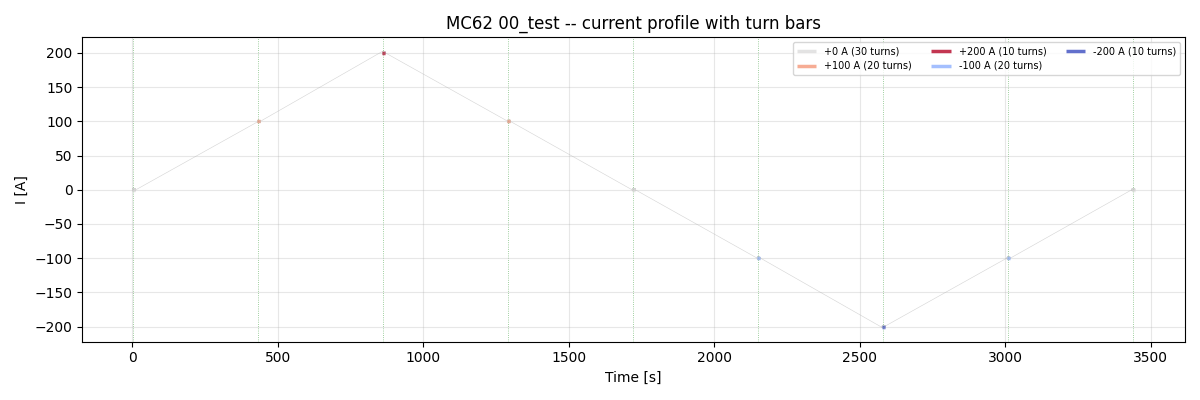

In [6]:
# ── Current profile with turn-bar overlay ──────────────────────────────
fig, ax = plt.subplots(figsize=(12, 4))

# Background: per-sample current (subsample for speed)
step = max(1, len(t_all_samples) // 80000)
ax.plot(t_all_samples[::step], I_all_samples[::step],
        linewidth=0.4, color="lightgrey", zorder=0)

# Colour palette per nominal current level
unique_I = sorted(df_turns["I_nom"].unique())
cmap = plt.cm.coolwarm
norm_c = plt.Normalize(min(unique_I), max(unique_I))
plateau_colors = {I: cmap(norm_c(I)) for I in unique_I}

# Draw each turn as a horizontal bar at its mean current
drawn_labels = set()
for _, row in df_turns.iterrows():
    I_nom = row["I_nom"]
    col = plateau_colors[I_nom]
    kw = {}
    lbl_key = f"{I_nom:+.0f} A"
    if lbl_key not in drawn_labels:
        n_at = int((df_turns["I_nom"] == I_nom).sum())
        kw["label"] = f"{lbl_key} ({n_at} turns)"
        drawn_labels.add(lbl_key)
    ax.plot([row["t_start"], row["t_end"]],
            [row["I_mean"], row["I_mean"]],
            linewidth=2.5, color=col, alpha=0.8,
            solid_capstyle="butt", zorder=2, **kw)

# Mark the "last N turns" window within each run
for run_id in df_turns["run_id"].unique():
    rdf = df_turns[df_turns["run_id"] == run_id].sort_values("turn_in_run")
    n_total = len(rdf)
    if n_total > N_LAST_TURNS:
        boundary_turn = rdf.iloc[n_total - N_LAST_TURNS]
        ax.axvline(boundary_turn["t_start"], color="green",
                   lw=0.6, ls=":", alpha=0.5, zorder=1)

ax.set_xlabel("Time [s]")
ax.set_ylabel("I [A]")
ax.set_title("MC62 00_test -- current profile with turn bars")
ax.legend(loc="upper right", fontsize=7, ncol=3)
fig.tight_layout()
plt.show()

## 3c. cel/fed Safety Diagnostic

Run `diagnose_cel_fed()` on the highest-|I| run for each PCB to check
whether the centre-location + feeddown correction is safe for this data.
For dipoles, cel uses compensated harmonics n=10,11 which can be pure
noise at low SNR.  See `correction_options_reference.md` for background.

In [7]:
def _cel_fed_check(runs, kn, label):
    """Run cel/fed diagnostic on the highest-|I| run."""
    peak = max(runs, key=lambda r: abs(r["I_nom"]))
    raw = np.loadtxt(peak["file"])
    nt = raw.shape[0] // Ns
    raw = raw[:nt * Ns]
    rr1, rr2 = robust_range(raw[:, 1]), robust_range(raw[:, 2])
    sw = rr2 > rr1
    shape = (nt, Ns)
    t = raw[:, 0].reshape(shape)
    fa = raw[:, 2 if sw else 1].reshape(shape)
    fc = raw[:, 1 if sw else 2].reshape(shape)
    Ia = raw[:, 3].reshape(shape)
    d = diagnose_cel_fed(fa, fc, t, Ia, kn=kn, r_ref=R_REF,
                         magnet_order=MAGNET_ORDER)
    print(f"[{label}] Run {peak['run_id']} (I={peak['I_nom']:+.0f} A): "
          f"{d.recommendation}")
    print(f"  {d.reason}")
    Bd = np.max(np.abs(d.B_main_with_fed - d.B_main_without_fed))
    print(f"  B_main max |diff|: {Bd:.4e} T\n")
    return d

diag_int = _cel_fed_check(runs_integral, kn_integral, "Integral")
diag_cen = _cel_fed_check(runs_central, kn_central, "Central")

# Act on diagnostic: disable cel/fed if either segment is unsafe
if diag_int.recommendation == "UNSAFE" or diag_cen.recommendation == "UNSAFE":
    OPTIONS = tuple(o for o in OPTIONS if o not in ("cel", "fed"))
    print(f"\ncel/fed disabled, OPTIONS = {OPTIONS}")
else:
    print(f"\ncel/fed safe, keeping OPTIONS = {OPTIONS}")


[Integral] Run 2 (I=+200 A): UNSAFE
  10/10 turns (100%) have |zR| > 0.0100 (median 0.4869, max 0.4876). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 1.6516e-03 T



[Central] Run 2 (I=+200 A): UNSAFE
  10/10 turns (100%) have |zR| > 0.0100 (median 0.0532, max 0.1435). cel/fed produces unreliable offsets — skip it and use OPTIONS = ('dri', 'rot').
  B_main max |diff|: 9.5036e-06 T


cel/fed disabled, OPTIONS = ('dri', 'rot')


## 4. Process All Runs Through Kn Pipeline

Each run (one plateau) is processed independently through the Kn pipeline.

### Pipeline steps (Bottura notation)

The pipeline applies a chain of corrections controlled by `OPTIONS`. Note: cel/fed is diagnosed at runtime — if UNSAFE for this dipole, it is disabled.

| Step | Option | Formula |
|:-----|:-------|:--------|
| 1. Drift correction | `dri` | $\Phi = \text{cumsum}(\Delta\Phi - \langle\Delta\Phi\rangle) - \langle\text{cumsum}(\Delta\Phi)\rangle$ (legacy mode) |
| 2. FFT | — | $\hat{\Phi}_n = \frac{2}{N_s} \cdot \text{FFT}(\Phi)[n], \quad n = 1, \ldots, H$ |
| 3. Kn application | — | $C_n = \hat{\Phi}_n \cdot R_{\rm ref}^{\,n-1} \,/\, \overline{K_n}$ |
| 4. Rotation | `rot` | $\phi = \frac{1}{m} \arg(C_m); \quad C_n \to C_n \cdot e^{-in\phi}$ (Bottura Eq. AIV.6) |
| 5. Centre location | `cel` | $z_R = -C_{m-1}/[(m-1)\,C_m]$ — *disabled if UNSAFE for dipole* |
| 6. Feeddown | `fed` | $C'_n = \sum_{k=n}^{H} \binom{k}{n} z_R^{k-n} C_k$ — *disabled if UNSAFE* |
| 7. Merge | — | abs channel for $n \leq m$, compensated for $n > m$ |
| 8. Normalisation | — | $b_n + i\,a_n = (C_n / \text{Re}(C_m)) \times 10^4$, for $n > m$ |

Turns with $|B_1| <$ `MIN_B1_T` are flagged `ok_main = False` and get NaN units.

### Why cel/fed may be disabled for dipoles

Dipole centre-location uses compensated harmonics $n = 10, 11$ (high-order, weak signal): $z_R = -C_{10}^{\rm cmp} / (10 \cdot C_{11}^{\rm cmp})$. At low current or poor SNR, these harmonics are unreliable and $|z_R|$ becomes unphysically large. For quadrupoles ($m \geq 2$), CEL uses the robust ratio $C_{m-1}/C_m$ (adjacent orders, strong signal).


In [8]:
def load_and_process_runs(runs, kn, label, merge_mode="abs_upto_m_cmp_above"):
    all_rows = []

    # Channel detection from highest-current run
    peak_run = max(runs, key=lambda r: abs(r["I_nom"]))
    raw_peak = np.loadtxt(peak_run["file"])
    rr1 = robust_range(raw_peak[:, 1])
    rr2 = robust_range(raw_peak[:, 2])
    swap = rr2 > rr1
    print(f"[{label}] col1 range={rr1:.3e}, col2 range={rr2:.3e}"
          f"  ->  {'SWAP' if swap else 'no swap'}"
          f"  |  merge: {merge_mode}")

    # Hysteresis branch direction
    I_noms = [r["I_nom"] for r in runs]
    branches = ["ascending"]
    for i in range(1, len(I_noms)):
        if I_noms[i] > I_noms[i - 1]:
            branches.append("ascending")
        elif I_noms[i] < I_noms[i - 1]:
            branches.append("descending")
        else:
            branches.append(branches[-1])

    for ri, run_info in enumerate(runs):
        raw = np.loadtxt(run_info["file"])
        n_turns = raw.shape[0] // Ns
        raw = raw[: n_turns * Ns]

        t_turns  = raw[:, 0].reshape(n_turns, Ns)
        ch1      = raw[:, 1].reshape(n_turns, Ns)
        ch2      = raw[:, 2].reshape(n_turns, Ns)
        flux_abs = ch2 if swap else ch1
        flux_cmp = ch1 if swap else ch2
        # Column 3 is DCCT current (already in Amperes)
        I_turns  = raw[:, 3].reshape(n_turns, Ns)

        try:
            result, C_merged, C_units, ok_main = process_kn_pipeline(
                flux_abs, flux_cmp, t_turns, I_turns, kn, R_REF,
                MAGNET_ORDER,
                options=OPTIONS, drift_mode=DRIFT_MODE,
                min_b1_T=MIN_B1_T,
                merge_mode=merge_mode,
                flip_signal_polarity=FLIP_SIGNAL_POLARITY,
                encoder_offset_rad=ENCODER_OFFSET_RAD,
            )
            extra = [{"run_id": run_info["run_id"],
                       "I_nom": run_info["I_nom"],
                       "branch": branches[ri],
                       "turn_in_run": t,
                       "pcb": label}
                      for t in range(n_turns)]
            rows = build_harmonic_rows(
                result, C_merged, C_units, ok_main,
                MAGNET_ORDER, extra)
            all_rows.extend(rows)
            n_ok = int(sum(ok_main))
            I_actual = I_turns.mean()
            print(f"  Run {run_info['run_id']:02d} "
                  f"(I_nom={run_info['I_nom']:+7.1f} A, "
                  f"I_meas={I_actual:+7.1f} A): "
                  f"{n_turns} turns, {n_ok} ok")
        except Exception as e:
            print(f"  Run {run_info['run_id']:02d} "
                  f"({run_info['I_nom']:+7.1f} A): FAILED - {e}")

    return pd.DataFrame(all_rows)

print("Processing Integral PCB (R45)...")
df_int = load_and_process_runs(runs_integral, kn_integral, "Integral")
print(f"\nProcessing Central PCB (DQ) -- merge_mode='abs_all' (cmp SNR too low)...")
df_cen = load_and_process_runs(runs_central, kn_central, "Central",
                               merge_mode="abs_all")


print(f"\nIntegral: {len(df_int)} rows  |  Central: {len(df_cen)} rows")

Processing Integral PCB (R45)...
[Integral] col1 range=4.097e-03, col2 range=1.604e-04  ->  no swap  |  merge: abs_upto_m_cmp_above
  Run 00 (I_nom=   +0.0 A, I_meas=   -0.0 A): 10 turns, 10 ok
  Run 01 (I_nom= +100.0 A, I_meas= +100.0 A): 10 turns, 10 ok
  Run 02 (I_nom= +200.0 A, I_meas= +200.0 A): 10 turns, 10 ok
  Run 03 (I_nom= +100.0 A, I_meas= +100.0 A): 10 turns, 10 ok
  Run 04 (I_nom=   +0.0 A, I_meas=   +0.0 A): 10 turns, 10 ok
  Run 05 (I_nom= -100.0 A, I_meas= -100.0 A): 10 turns, 10 ok
  Run 06 (I_nom= -200.0 A, I_meas= -200.0 A): 10 turns, 10 ok
  Run 07 (I_nom= -100.0 A, I_meas= -100.0 A): 10 turns, 10 ok
  Run 08 (I_nom=   +0.0 A, I_meas=   +0.0 A): 10 turns, 10 ok

Processing Central PCB (DQ) -- merge_mode='abs_all' (cmp SNR too low)...
[Central] col1 range=1.483e-04, col2 range=9.227e-08  ->  no swap  |  merge: abs_all
  Run 00 (I_nom=   +0.0 A, I_meas=   -0.0 A): 10 turns, 10 ok
  Run 01 (I_nom= +100.0 A, I_meas= +100.0 A): 10 turns, 10 ok
  Run 02 (I_nom= +200.0 A, 

## 5. Plateau Quality & Averaging

For each run, select the **last** $N_{\rm last}$ turns to let eddy currents settle, then compute per-plateau statistics.

### Settled-turn averaging

For run $r$ with $N_r$ plateau turns, the averaging window is:

$$
\text{turns used} = [N_r - N_{\rm last},\; N_r) \quad \text{where } N_{\rm last} = 10
$$

This corresponds to 10 s of settling at 1 Hz, chosen to exceed $5 \times \tau_{\rm max}$ (the eddy-current time constant at low current; see eddy-current notebook for the fit results).

### Per-plateau statistics

$$
\bar{B}_1^{(r)} = \frac{1}{N_{\rm ok}} \sum_{k \in \text{settled}} B_{1,k}, \qquad
\sigma_{B_1}^{(r)} = \sqrt{\frac{1}{N_{\rm ok}-1} \sum_{k} (B_{1,k} - \bar{B}_1)^2}
$$

Similarly for each $b_n$, $a_n$. A plateau is flagged `quality = "good"` if $N_{\rm ok} \geq \max(1, N_{\rm last}/2)$.

### Transfer function

$$
\text{TF}(I) = \frac{\bar{B}_1}{I_{\rm nom} / 1000} \quad [\text{T/kA}]
$$

Only computed for $|I_{\rm nom}| > 1$ A (zero-current plateaus give undefined TF).


In [9]:
summ_int = plateau_summary(df_int, N_LAST_TURNS)
summ_cen = plateau_summary(df_cen, N_LAST_TURNS)

cols_show = ["run_id", "I_nom", "branch", "n_ok",
             "B1_mean", "B1_std", "quality"]
print("=== Integral PCB (R45) ===")
print(summ_int[cols_show].to_string(index=False, float_format="%.6f"))
print(f"\n=== Central PCB (DQ) ===")
print(summ_cen[cols_show].to_string(index=False, float_format="%.6f"))

=== Integral PCB (R45) ===
 run_id       I_nom     branch  n_ok   B1_mean   B1_std quality
      0    0.000000  ascending     8 -0.001120 0.000067    good
      1  100.000000  ascending     8  0.131624 0.000845    good
      2  200.000000  ascending     8  0.229322 0.000470    good
      3  100.000000 descending     8  0.136651 0.000046    good
      4    0.000000 descending     8  0.001818 0.000227    good
      5 -100.000000 descending     8 -0.131594 0.000870    good
      6 -200.000000 descending     8 -0.229604 0.000390    good
      7 -100.000000  ascending     8 -0.136698 0.000049    good
      8    0.000000  ascending     8 -0.001754 0.000202    good

=== Central PCB (DQ) ===
 run_id       I_nom     branch  n_ok   B1_mean   B1_std quality
      0    0.000000  ascending     8 -0.001811 0.000118    good
      1  100.000000  ascending     8  0.216032 0.001367    good
      2  200.000000  ascending     8  0.376684 0.000783    good
      3  100.000000 descending     8  0.223969 0.00

## 6. Eddy-Current Settling — B1 vs Turn Number

Turn-by-turn evolution within each plateau.  The grey dashed line marks
the boundary of the **last N turns** selection window.

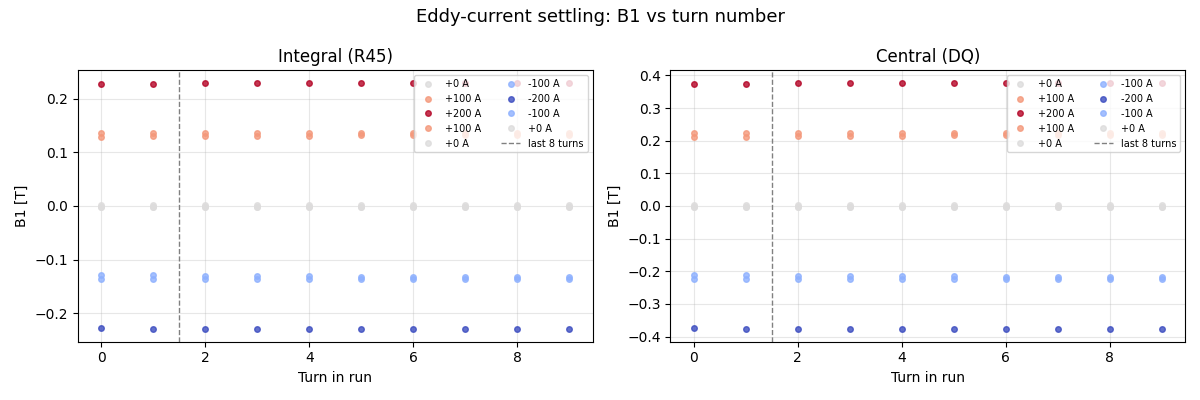

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, df, label in [(axes[0], df_int, "Integral (R45)"),
                       (axes[1], df_cen, "Central (DQ)")]:
    cmap = plt.cm.coolwarm
    all_runs = sorted(df["run_id"].unique())
    I_min = df["I_nom"].min()
    I_max = df["I_nom"].max()
    norm = plt.Normalize(I_min, I_max)

    for run_id in all_runs:
        rdf = df[df["run_id"] == run_id].sort_values("turn_in_run")
        ok = rdf["ok_main"].astype(bool)
        if not ok.any():
            continue
        I_nom = rdf["I_nom"].iloc[0]
        color = cmap(norm(I_nom))
        ax.plot(rdf.loc[ok, "turn_in_run"], rdf.loc[ok, "B1_T"],
                "o", ms=4, color=color, alpha=0.8,
                label=f"{I_nom:+.0f} A")

    n_total_max = df.groupby("run_id")["turn_in_run"].max().max()
    ax.axvline(x=n_total_max - N_LAST_TURNS + 0.5,
               ls="--", color="gray", lw=1,
               label=f"last {N_LAST_TURNS} turns")
    ax.set_xlabel("Turn in run")
    ax.set_ylabel("B1 [T]")
    ax.set_title(label)
    ax.legend(fontsize=7, ncol=2)

fig.suptitle("Eddy-current settling: B1 vs turn number", fontsize=13)
fig.tight_layout()
plt.show()

## 7. B1 (Main Dipole Field) vs Current — Hysteresis

Averaged over last N turns.  **Blue** = ascending, **Red** = descending.
Grey arrows show the measurement traversal order (the "direction of going").

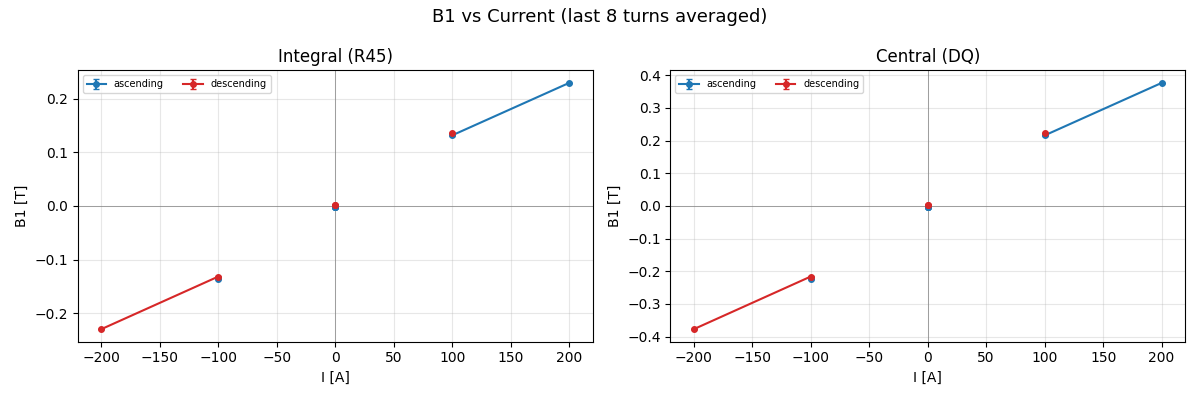

In [11]:
branch_colors = {"ascending": "tab:blue", "descending": "tab:red"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "B1_mean", "B1_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("B1 [T]")
    ax.set_title(label)
    ax.legend(fontsize=7, ncol=2)
    ax.axhline(0, color="gray", lw=0.5)
    ax.axvline(0, color="gray", lw=0.5)

fig.suptitle(f"B1 vs Current (last {N_LAST_TURNS} turns averaged)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 8. b2 (Quadrupole) vs Current

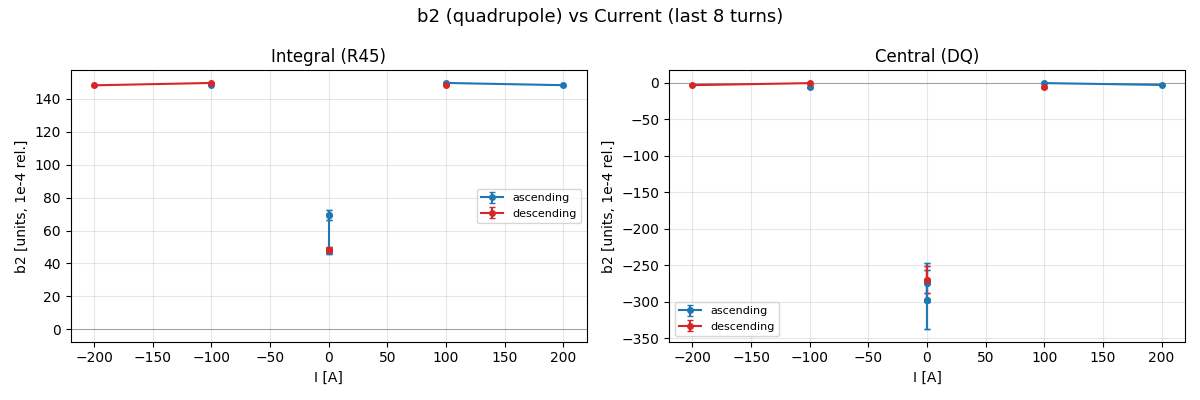

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "b2_units_mean", "b2_units_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b2 [units, 1e-4 rel.]")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle(f"b2 (quadrupole) vs Current (last {N_LAST_TURNS} turns)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 9. b3 (Sextupole) vs Current

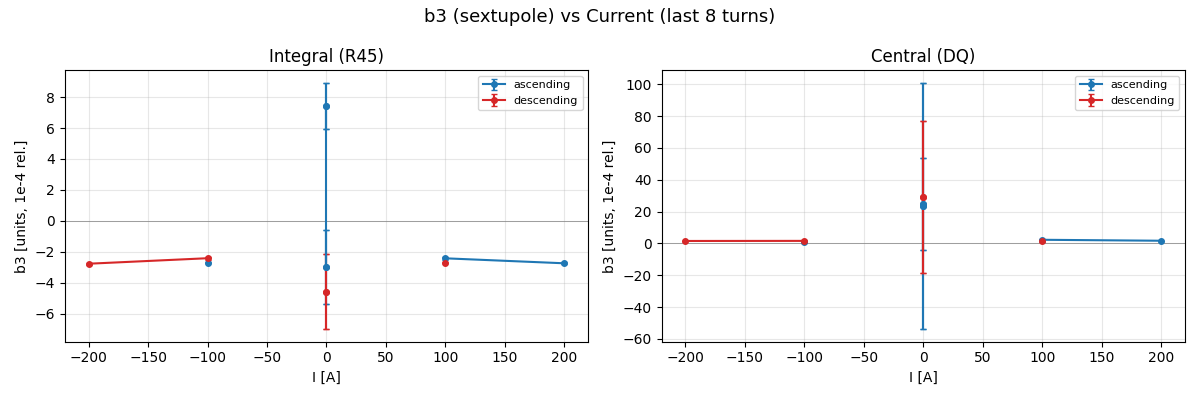

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "b3_units_mean", "b3_units_std")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("b3 [units, 1e-4 rel.]")
    ax.set_title(label)
    ax.legend(fontsize=8)
    ax.axhline(0, color="gray", lw=0.5)

fig.suptitle(f"b3 (sextupole) vs Current (last {N_LAST_TURNS} turns)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 10. Transfer Function  B1 / I  vs I

Excludes 0 A runs (undefined).  Saturation appears as a drop in TF at
high |I|.

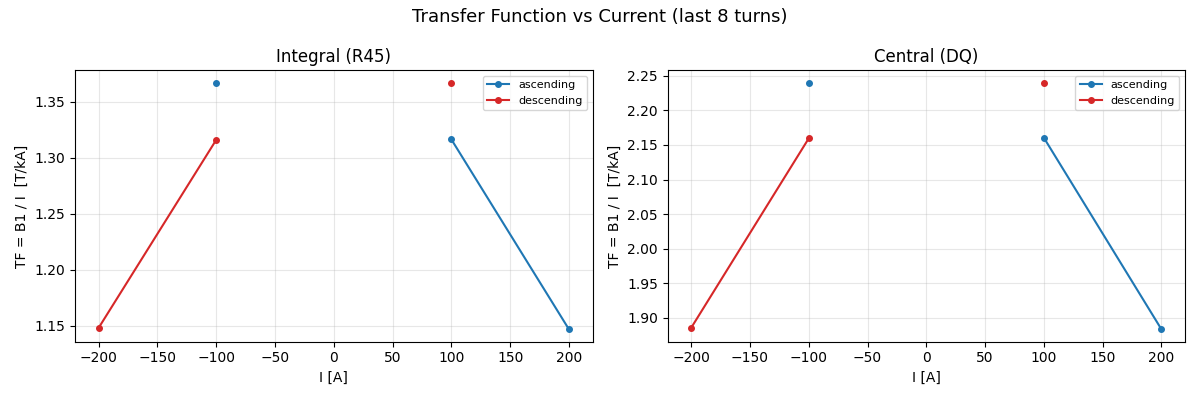

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    plot_hysteresis(ax, summ, "I_nom", "TF")
    ax.set_xlabel("I [A]")
    ax.set_ylabel("TF = B1 / I  [T/kA]")
    ax.set_title(label)
    ax.legend(fontsize=8)

fig.suptitle(f"Transfer Function vs Current (last {N_LAST_TURNS} turns)",
             fontsize=13)
fig.tight_layout()
plt.show()

## 11. Multipole Spectrum at Peak Current

Bar chart of normal (bn) and skew (an) harmonics at the
highest-current good plateau.

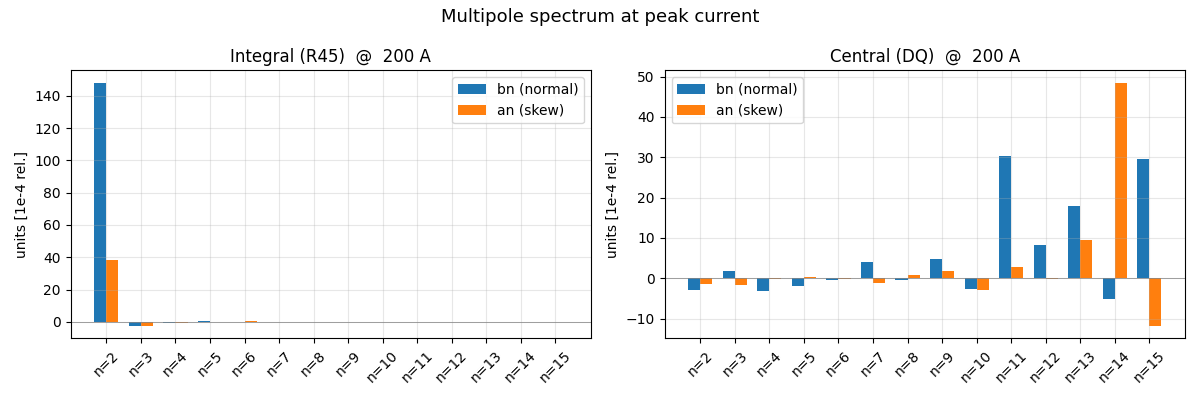

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, summ, label in [(axes[0], summ_int, "Integral (R45)"),
                          (axes[1], summ_cen, "Central (DQ)")]:
    # Pick highest |I| good plateau
    good = summ[summ["quality"] == "good"]
    if good.empty:
        ax.set_title(f"{label}: no valid data")
        continue
    peak = good.loc[good["I_nom"].abs().idxmax()]

    orders, bn, an = [], [], []
    for n in range(2, 16):
        bc = f"b{n}_units_mean"
        ac = f"a{n}_units_mean"
        if bc in summ.columns and pd.notna(peak.get(bc)):
            orders.append(n)
            bn.append(peak[bc])
            an.append(peak.get(ac, 0.0) if pd.notna(peak.get(ac)) else 0.0)

    if orders:
        x = np.arange(len(orders))
        w = 0.35
        ax.bar(x - w / 2, bn, w, label="bn (normal)", color="tab:blue")
        ax.bar(x + w / 2, an, w, label="an (skew)", color="tab:orange")
        ax.set_xticks(x)
        ax.set_xticklabels([f"n={o}" for o in orders], rotation=45)
        ax.set_ylabel("units [1e-4 rel.]")
        ax.set_title(f"{label}  @  {peak['I_nom']:.0f} A")
        ax.legend()
        ax.axhline(0, color="gray", lw=0.5)

fig.suptitle("Multipole spectrum at peak current", fontsize=13)
fig.tight_layout()
plt.show()

## 12. Summary Table

In [16]:
def format_summary(summ, label):
    print(f"\n{'=' * 85}")
    print(f"  {label}")
    print(f"  R_ref = {R_REF*1e3:.1f} mm  |  "
          f"last {N_LAST_TURNS} turns averaged")
    print(f"{'=' * 85}")
    hdr = (f"{'Run':>4s} {'I [A]':>8s} {'Branch':>10s} "
           f"{'B1 [T]':>12s} {'b2 [units]':>12s} "
           f"{'b3 [units]':>12s} {'TF [T/kA]':>10s} {'Qual':>5s}")
    print(hdr)
    print("-" * 85)
    for _, r in summ.iterrows():
        b1 = f"{r['B1_mean']:.6f}" if pd.notna(r['B1_mean']) else "---"
        b2 = (f"{r.get('b2_units_mean', np.nan):.2f}"
              if pd.notna(r.get('b2_units_mean')) else "---")
        b3 = (f"{r.get('b3_units_mean', np.nan):.2f}"
              if pd.notna(r.get('b3_units_mean')) else "---")
        tf = f"{r['TF']:.4f}" if pd.notna(r['TF']) else "---"
        print(f"{r['run_id']:4.0f} {r['I_nom']:+8.1f} "
              f"{r['branch']:>10s} {b1:>12s} {b2:>12s} "
              f"{b3:>12s} {tf:>10s} {r['quality']:>5s}")

format_summary(summ_int, "Integral PCB (R45)")
format_summary(summ_cen, "Central PCB (DQ)")


  Integral PCB (R45)
  R_ref = 33.0 mm  |  last 8 turns averaged
 Run    I [A]     Branch       B1 [T]   b2 [units]   b3 [units]  TF [T/kA]  Qual
-------------------------------------------------------------------------------------
   0     +0.0  ascending    -0.001120        69.21         7.44        ---  good
   1   +100.0  ascending     0.131624       149.60        -2.43     1.3162  good
   2   +200.0  ascending     0.229322       148.24        -2.75     1.1466  good
   3   +100.0 descending     0.136651       148.41        -2.71     1.3665  good
   4     +0.0 descending     0.001818        48.22        -4.60        ---  good
   5   -100.0 descending    -0.131594       149.60        -2.42     1.3159  good
   6   -200.0 descending    -0.229604       148.17        -2.78     1.1480  good
   7   -100.0  ascending    -0.136698       148.37        -2.70     1.3670  good
   8     +0.0  ascending    -0.001754        47.64        -2.98        ---  good

  Central PCB (DQ)
  R_ref = 33.0 mm 

## 13. Export to CSV (optional)

In [17]:
# Uncomment to save:
# out = Path(r"C:\Users\albellel\python-projects\rotating-coil-analyzer\output")
# out.mkdir(exist_ok=True)
# summ_int.to_csv(out / "MC62_00_test_integral_summary.csv", index=False)
# summ_cen.to_csv(out / "MC62_00_test_central_summary.csv", index=False)
# df_int.to_csv(out / "MC62_00_test_integral_all_turns.csv", index=False)
# df_cen.to_csv(out / "MC62_00_test_central_all_turns.csv", index=False)
# print("Saved to", out)